## in EDA what things we do
1. Missing Value
2. Explore about the num var
3. Explore about the categorical var
4. Finding Relationships between features

# Types of data values
int64 means integer variable, object means categorical variable/text data/int variable, float64 means floating values.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

using isnull.sum() we can see that there are no null values in any column is this dataset

# basic structure for a dataset:
1. df.shape : tells the no. of (rows,columns).
2. df.head() : fetches the first 5 records.
3. df.tail() : fetches the last 5 records.
4. df.info() : gives infoo about the dataset.
5. df.describe() : tells us meaningful info about the data ex. mean,max,min,median.
6. df.columns : no. of columns.
7. df.dtypes : tells the data type.
8. df.nunique(): tells about unique values in each column.

# Accessing Data with Pandas
1. df
2. df.loc[start:end] : used to fetch the records or rows or also we an write df.loc[3:9,"column name"]
3. df.index


In [49]:
df = pd.read_csv("Heart.csv")

In [50]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [51]:
df.shape

(918, 12)

In [52]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [54]:
df.sample()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [57]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [61]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [68]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [69]:
df["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [70]:
df["ExerciseAngina"].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [71]:
df["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [ ]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

# Interpretation
1. Sex : M is more common
2. ChestPainType : ASY is much more common than TA
3. ST_Slope : down is more common than flat/up
4. min cholesterol is 0 which is unlikely!!
5. restingBP is also 0 which is unusual!!

In [79]:
(df["RestingBP"]==0).sum()
df[df["RestingBP"]==0]["HeartDisease"].value_counts()

HeartDisease
1    1
Name: count, dtype: int64

In [78]:
(df["Cholesterol"]==0).sum()
df[df["Cholesterol"]==0]["HeartDisease"].value_counts()

HeartDisease
1    152
0     20
Name: count, dtype: int64

In [5]:
import pandas as pd
df = pd.read_csv("Heart.csv")

In [7]:
pd.crosstab(df["Sex"],df["HeartDisease"],normalize="index")

HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


In [ ]:
pd.crosstab(df["ChestPainType"],df["HeartDisease"],normalize="index")

HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


In [9]:
pd.crosstab(
    df["ExerciseAngina"],
    df["HeartDisease"],
    normalize="index")

HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


In [10]:
pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"],
    normalize="index")

HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


In [11]:
pd.crosstab(
    df["RestingECG"],
    df["HeartDisease"],
    normalize="index")

HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


In [ ]:
df.groupby("HeartDisease")["Age"].agg(
    ["mean", "median", "min", "max"])

# NOTE:
for nummerical values we use groupby and it calculates different things such as min,max,avg,median that is related to the other column. 

In [12]:
df.groupby("HeartDisease")["RestingBP"].agg(
    ["mean", "median", "min", "max"])

,mean,median,min,max
HeartDisease,,,,
0,130.180488,130.0,80,190
1,134.185039,132.0,0,200


In [13]:
df.groupby("HeartDisease")["Cholesterol"].agg(
    ["mean", "median", "min", "max"])

,mean,median,min,max
HeartDisease,,,,
0,227.121951,227.0,0,564
1,175.940945,217.0,0,603


In [14]:
df.groupby("HeartDisease")["MaxHR"].agg(
    ["mean", "median", "min", "max"])

,mean,median,min,max
HeartDisease,,,,
0,148.151220,150.0,69,202
1,127.655512,126.0,60,195


In [15]:
df.groupby("HeartDisease")["Oldpeak"].agg(
    ["mean", "median", "min", "max"])

,mean,median,min,max
HeartDisease,,,,
0,0.408049,0.0,-1.1,4.2
1,1.274213,1.2,-2.6,6.2


In [17]:
df.groupby("HeartDisease")[
    ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
].mean()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
HeartDisease,,,,,
0,50.551220,130.180488,227.121951,148.151220,0.408049
1,55.899606,134.185039,175.940945,127.655512,1.274213


from this we can see that for HD=1, this grup has higher avg Age, RestingBP,OldPeak while it has lower avg MaxHR and Cholesterol but for Cholesterol we need to first deal with the 172 records which has 0 in them as they can be wrong. 

# Relation Between Columns:
now we calculate hoow numerical variables are related with each other, so vwe calculate the correlation b/w num columns.

In [16]:
df.corr(numeric_only=True)["HeartDisease"].sort_values(ascending=False)

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64

# Plotting Section begins

In [25]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

dots= outliners.
line inside the box = the median
whisker = the spread
box= middle 50% of all values

# Numerical Vs Numerical Relationships

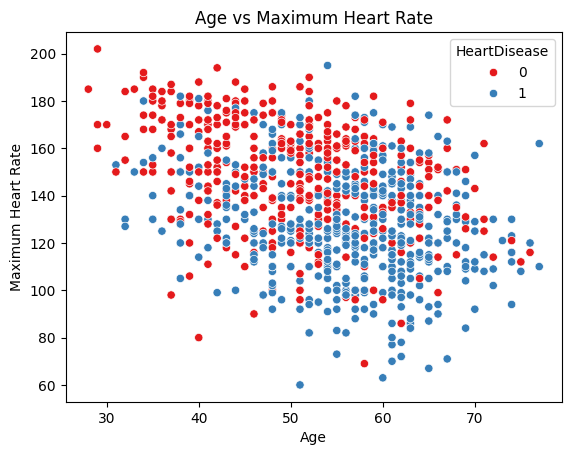

In [55]:
sns.scatterplot(data=df, x="Age", y="MaxHR", hue="HeartDisease", palette="Set1")

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")

plt.show()

# Insight: (Max_HR Vs Age)
The scatter plot shows a general negative relationship between Age and MaxHR, where maximum heart rate tends to decrease as age increases. The HeartDisease = 1 group also appears more concentrated at lower MaxHR values. However, substantial overlap exists between the two groups.

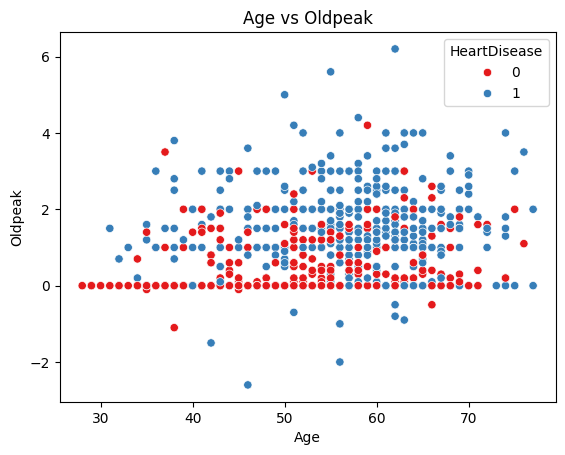

In [59]:
sns.scatterplot(
    data=df,
    x="Age",
    y="Oldpeak",
    hue="HeartDisease",
    palette="Set1")

plt.title("Age vs Oldpeak")
plt.xlabel("Age")
plt.ylabel("Oldpeak")

plt.show()

# Insight: (OldPeak Vs Age)
The scatter plot does not show a strong relationship between Age and Oldpeak. However, the HeartDisease = 1 group contains more observations at higher Oldpeak values, whereas HeartDisease = 0 is more concentrated around lower Oldpeak values.

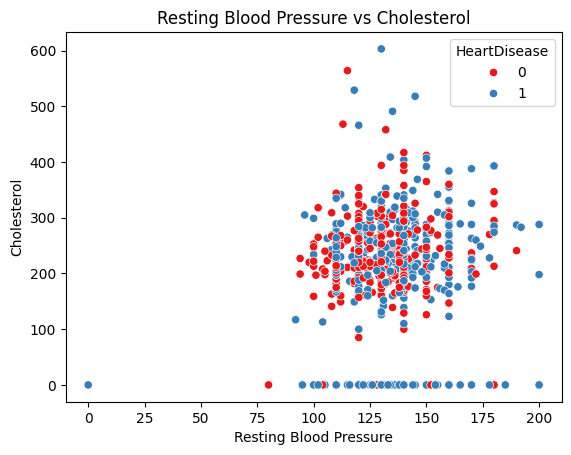

In [61]:
sns.scatterplot(
    data=df,
    x="RestingBP",
    y="Cholesterol",
    hue="HeartDisease",
    palette="Set1")

plt.title("Resting Blood Pressure vs Cholesterol")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Cholesterol")

plt.show()

# Insight: (Cholestrol Vs Resting BP)
No strong visible relationship between RestingBP and Cholesterol is observed. The large number of Cholesterol = 0 values should be treated as a data-quality concern or as a potential outliners.

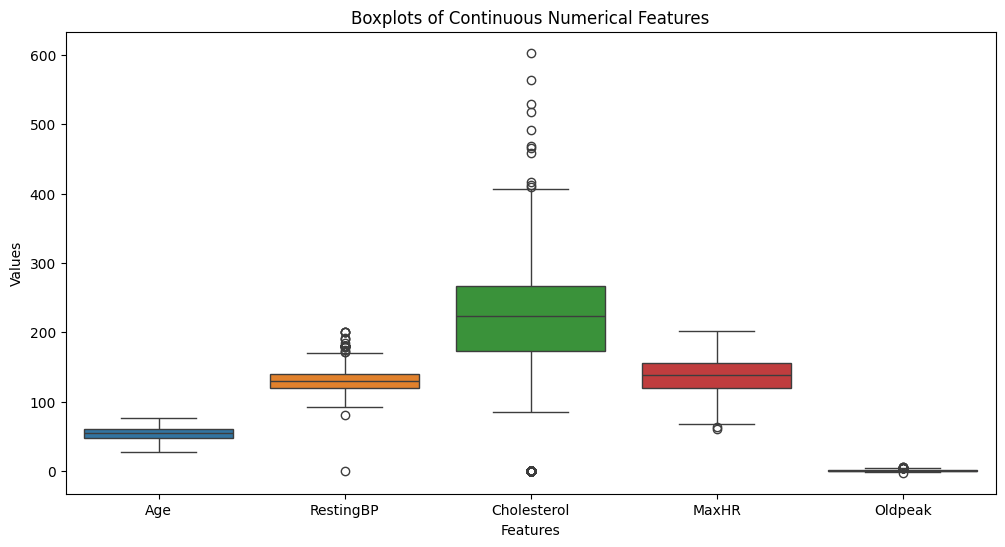

In [ ]:
continuous_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[continuous_columns])

plt.title("Boxplots of Continuous Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

# Insight:
the boxplots indicate the presence of some potential outliers in the numerical features, with Cholesterol showing the most noticeable extreme values. These values should be investigated before finalizing the data cleaning process.

# Data Cleaning:

In [72]:
df[df["Cholesterol"] == 0].shape

(172, 12)

In [ ]:
df[df["RestingBP"] == 0].shape

(1, 12)

In [74]:
print("Cholesterol = 0:")
print(df[df["Cholesterol"] == 0]["HeartDisease"].value_counts())

print("\nRestingBP = 0:")
print(df[df["RestingBP"] == 0]["HeartDisease"].value_counts())

Cholesterol = 0:
HeartDisease
1    152
0     20
Name: count, dtype: int64

RestingBP = 0:
HeartDisease
1    1
Name: count, dtype: int64


In [75]:
import numpy as np

df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

In [76]:
df.isnull().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [77]:
print("RestingBP median:", df["RestingBP"].median())
print("Cholesterol median:", df["Cholesterol"].median())

RestingBP median: 130.0
Cholesterol median: 237.0


In [78]:
df["RestingBP"] = df["RestingBP"].fillna(df["RestingBP"].median())
df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())

In [79]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [81]:
continuous_columns = ["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]

for col in continuous_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))


Age
Q1: 47.0
Q3: 60.0
IQR: 13.0
Lower bound: 27.5
Upper bound: 79.5
Number of outliers: 0

RestingBP
Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower bound: 90.0
Upper bound: 170.0
Number of outliers: 27

Cholesterol
Q1: 214.0
Q3: 267.0
IQR: 53.0
Lower bound: 134.5
Upper bound: 346.5
Number of outliers: 41

MaxHR
Q1: 120.0
Q3: 156.0
IQR: 36.0
Lower bound: 66.0
Upper bound: 210.0
Number of outliers: 2

Oldpeak
Q1: 0.0
Q3: 1.5
IQR: 1.5
Lower bound: -2.25
Upper bound: 3.75
Number of outliers: 16


In [82]:
df[(df["RestingBP"] < 90) | (df["RestingBP"] > 170)]["RestingBP"]


109    190.0
123    180.0
189    180.0
190    180.0
241    200.0
274    180.0
275    180.0
278    180.0
314     80.0
365    200.0
372    185.0
399    200.0
411    180.0
423    180.0
475    178.0
550    172.0
585    180.0
592    190.0
673    174.0
702    178.0
725    180.0
732    200.0
759    192.0
774    178.0
780    180.0
855    180.0
880    172.0
Name: RestingBP, dtype: float64

In [83]:
df[(df["Cholesterol"] < 134.5) | (df["Cholesterol"] > 346.5)]["Cholesterol"]


28     468.0
30     518.0
58     365.0
69     412.0
76     529.0
78     100.0
98      85.0
102    392.0
103    466.0
108    129.0
123    393.0
132    388.0
149    603.0
182    404.0
208    132.0
227    117.0
238    355.0
250    491.0
256    394.0
263    126.0
278    347.0
284    358.0
444    100.0
496    458.0
498    384.0
522    349.0
541    113.0
571    110.0
573    123.0
577    369.0
613    385.0
616    564.0
624    407.0
667    417.0
675    126.0
686    354.0
738    360.0
796    409.0
803    394.0
872    353.0
915    131.0
Name: Cholesterol, dtype: float64

In [84]:
df[(df["MaxHR"] < 66) | (df["MaxHR"] > 210)]["MaxHR"]

370    63
390    60
Name: MaxHR, dtype: int64

In [85]:
df[(df["Oldpeak"] < -2.25) | (df["Oldpeak"] > 3.75)]["Oldpeak"]

68     4.0
166    5.0
324   -2.6
500    4.0
521    4.0
537    4.0
559    4.0
624    4.0
702    4.2
732    4.0
771    5.6
775    3.8
791    4.2
850    6.2
900    4.4
908    4.0
Name: Oldpeak, dtype: float64

In [86]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [87]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,243.204793,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.990127,53.401297,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: ylabel='count'>

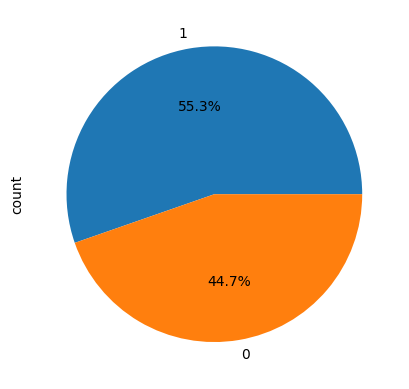

In [88]:
df["HeartDisease"].value_counts().plot.pie(autopct="%1.1f%%")

<Axes: ylabel='count'>

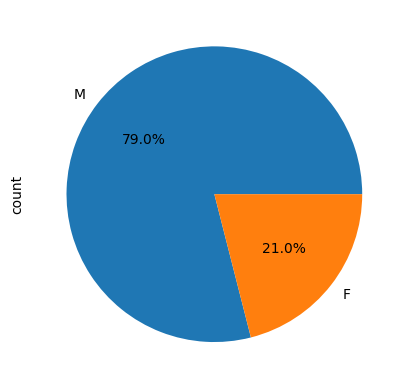

In [89]:
df["Sex"].value_counts().plot.pie(autopct="%1.1f%%")

<Axes: ylabel='count'>

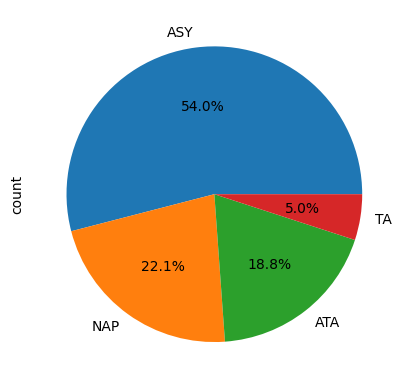

In [90]:
df["ChestPainType"].value_counts().plot.pie(autopct="%1.1f%%")

<Axes: ylabel='count'>

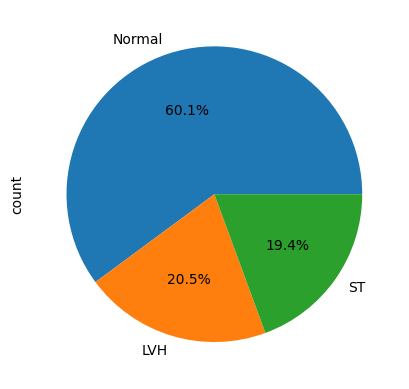

In [91]:
df["RestingECG"].value_counts().plot.pie(autopct="%1.1f%%")

<Axes: ylabel='count'>

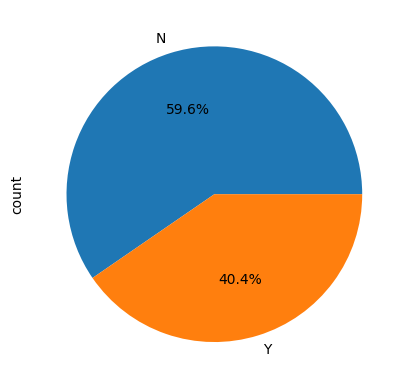

In [92]:
df["ExerciseAngina"].value_counts().plot.pie(autopct="%1.1f%%")

<Axes: ylabel='count'>

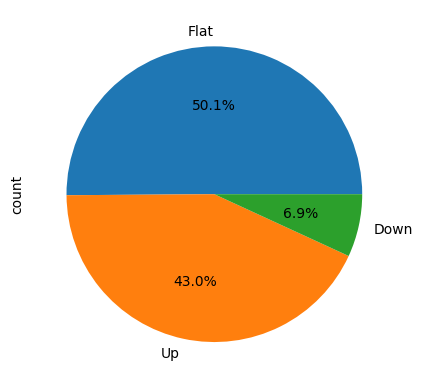

In [93]:
df["ST_Slope"].value_counts().plot.pie(autopct="%1.1f%%")

## Note for self:
1. sns.countplot creates a bar chart that shows how many records are present in each category.
2. hue="HeartDisease" tells seaborn to split each category acc to heatdisease column.


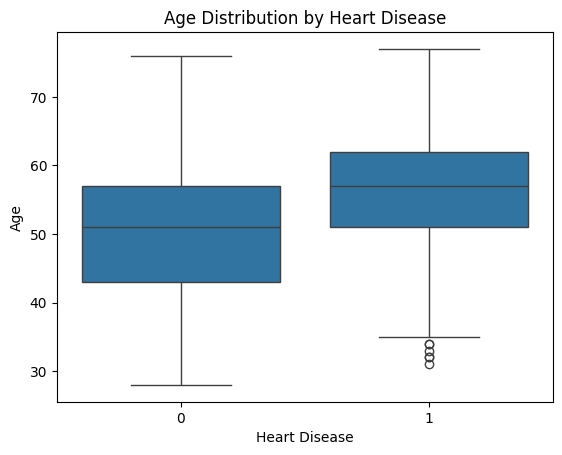

In [7]:
sns.boxplot(data=df, x="HeartDisease", y="Age")
plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()

# Insights: (Age)
the boxplt shows that the patients with heartdisease =1 have higher age distribution than those with HD=0. Also the Median age of HD=1 patients is higher with a few outliners having younger age values. 

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv("Heart.csv")

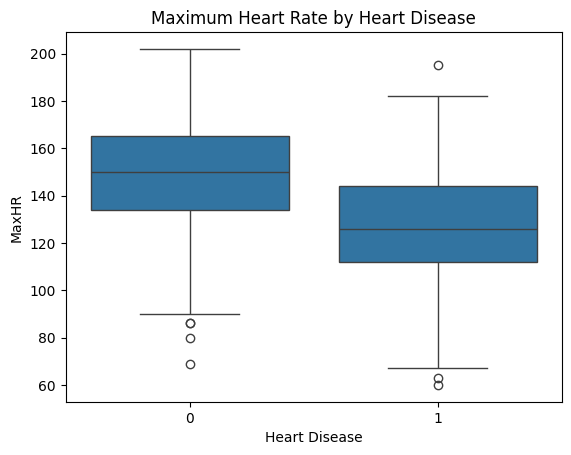

In [8]:
sns.boxplot(data=df, x="HeartDisease", y="MaxHR")
plt.title("Maximum Heart Rate by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("MaxHR")
plt.show()

# Insights: (Max HR)
the boxplt shows that the paitents with HD=1 have generally lower Max HR than HD=0 paitents.Also the median Max HR is lower for paitents with HR=1. however we can also see few outliners in both HR=0 as well as HR=1 paitents but these values do not become automatically wrong  

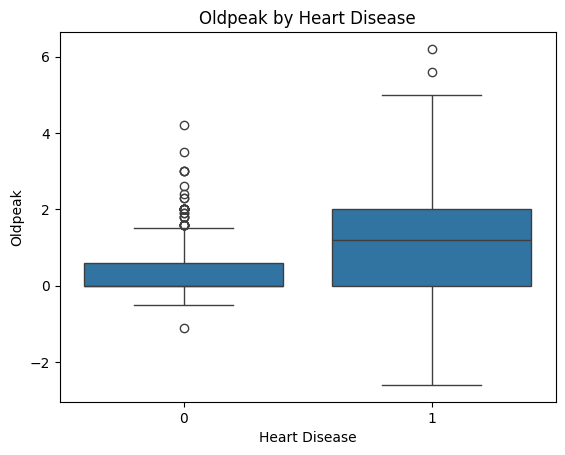

In [9]:
sns.boxplot(data=df, x="HeartDisease", y="Oldpeak")
plt.title("Oldpeak by Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Oldpeak")
plt.show()

# Insight: (OldPeak)
the  boxplt shows that the grup with HD=1 has higher oldpeak values than grup with HD=0. however there are potential outliners mainly in HD=0 grup

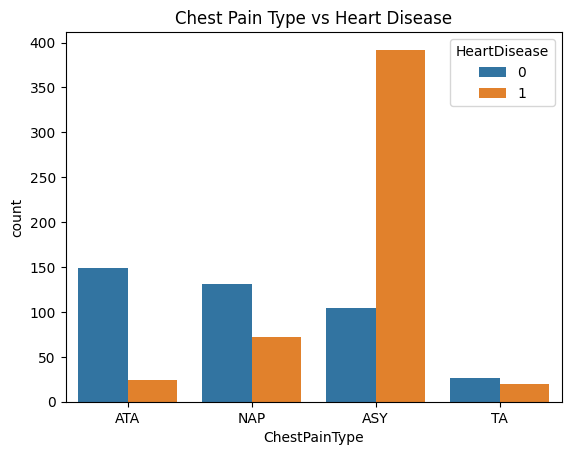

In [10]:
sns.countplot(data=df, x="ChestPainType", hue="HeartDisease")
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [16]:
pd.crosstab(
    df["ChestPainType"],
    df["HeartDisease"],
    normalize="index")

HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


# Insight: (ChestPainType)
In this dataset, the ASY chestpain category has the highest proportion of HD= 1 cases (79.03%), while ATA has the lowest (13.87%). This indicates an association between ChestPainType and HeartDisease in the dataset

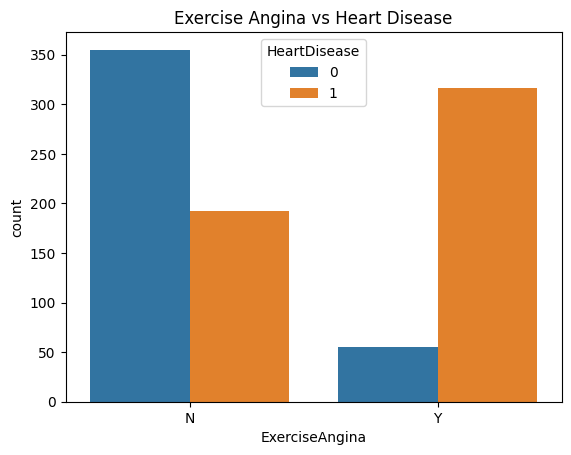

In [11]:
sns.countplot(data=df, x="ExerciseAngina", hue="HeartDisease")
plt.title("Exercise Angina vs Heart Disease")
plt.show()

In [17]:
pd.crosstab(
    df["ExerciseAngina"],
    df["HeartDisease"],
    normalize="index")

HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


# Insight: (Exercise Angina)
we can see from the plot that 85.18% of patients with EA have HD=1 compared with the 35.10% without EA. this indicates a strong association b/w EA and HD.

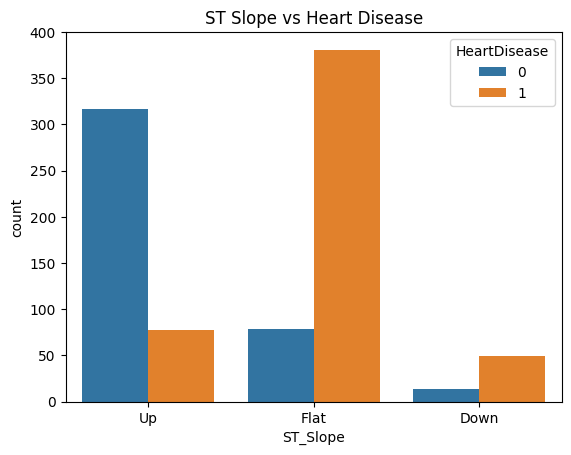

In [12]:
sns.countplot(data=df, x="ST_Slope", hue="HeartDisease")
plt.title("ST Slope vs Heart Disease")
plt.show()

In [18]:
pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"],
    normalize="index")

HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


#  Insight: (ST_Slope)
ST_Slope shows a strong association with HD. The Flat category has the highest proportion of HeartDisease = 1 cases (82.83%), while the Up category has the lowest (19.75%)

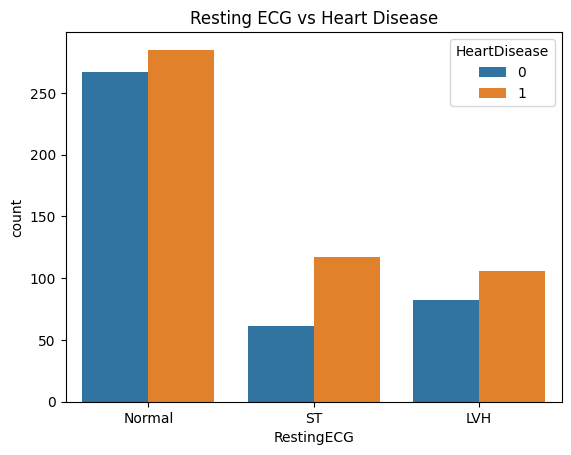

In [13]:
sns.countplot(data=df, x="RestingECG", hue="HeartDisease")
plt.title("Resting ECG vs Heart Disease")
plt.show()

In [19]:
pd.crosstab(
    df["RestingECG"],
    df["HeartDisease"],
    normalize="index")

HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


# Insight :(RestingECG)
the plt shows that RestingECG shows some association with the HD. the ST (65.7%) has highest proportion of HD=1, followed by LVH(56.38%) and Normal(51.63%).

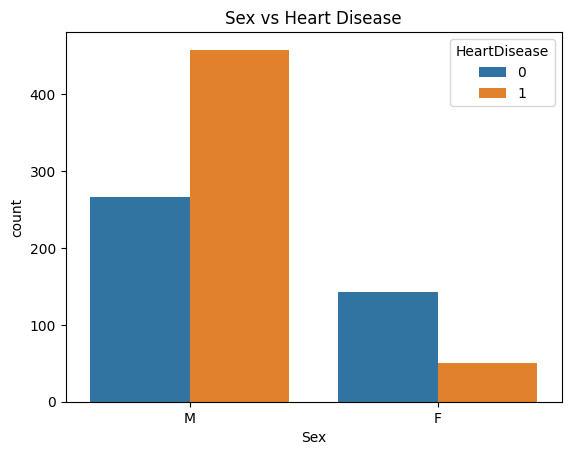

In [14]:
sns.countplot(data=df, x="Sex", hue="HeartDisease")
plt.title("Sex vs Heart Disease")
plt.show()

In [20]:
pd.crosstab(
    df["Sex"],
    df["HeartDisease"],
    normalize="index")

HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


# Insight: (Sex)
from the plt it is clear that in males about 63.17% of them show value HD=1. Whereas in case of females about 25.90% of them have HD=1 values, this shows that the proportion of HD=1 cases is higher among males than females 

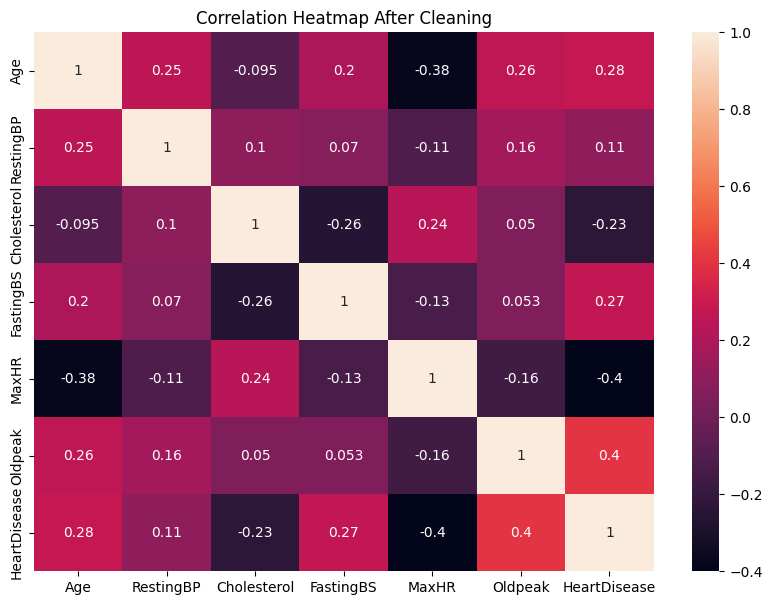

In [15]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap After Cleaning")
plt.show()

# Relationship with Heart Disease
between columns which are related to heartdisease.

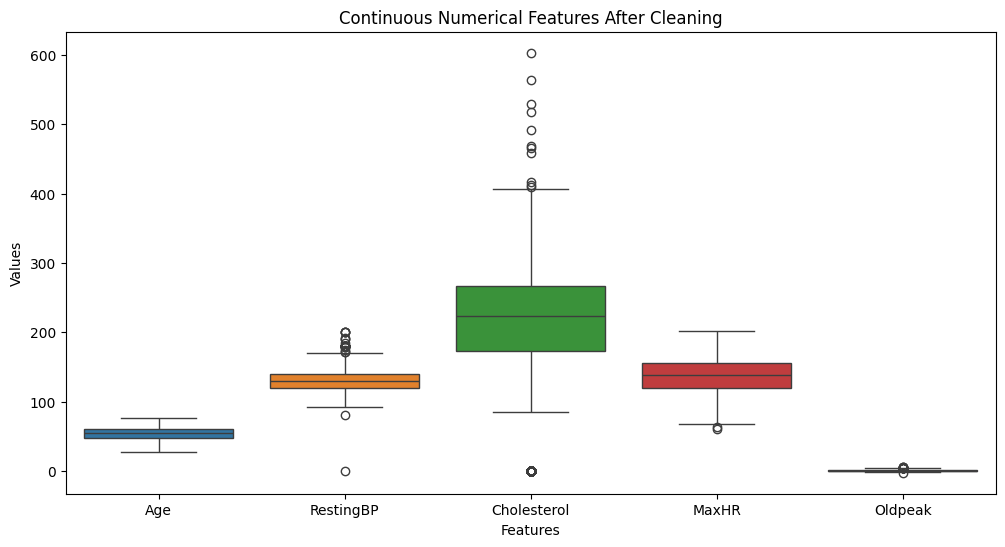

In [22]:
continuous_columns = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[continuous_columns])
plt.title("Continuous Numerical Features After Cleaning")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

# Conclusion Drawn:
After cleaning, the boxplots look more consistent, especially for Cholesterol and RestingBP. The extreme values that were still valid measurements have been retained, while the invalid zero values were replaced using the median.


In [21]:
df.corr(numeric_only=True)["HeartDisease"].sort_values(ascending=False)

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64

# Final EDA report:
1. the dataset given initially had no missing and duplicate rows.
2. I found some 0 values in Cholesterol (172 records) and RestingBP (1 record), which were not meaningful measurements, so I treated them as missing values and replaced them with the median of their respective columns.
3. I also checked the numerical columns for possible outliers using the IQR method. some unusual values were found, but they were still within possible real-world ranges, so I did not removed them.
4. After cleaning, I checked the dataset again and confirmed that there were no missing values left.